In [22]:
# IMPORT LIBRARIES

import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import matplotlib.pyplot as plt
import eelbrain
import numpy as np
from scipy import stats



# Comparing attended vs. unattended speech
Topographical scalp maps showing the grand average predictive power for attended vs. unattended speech along with relevant statistics.

In [23]:
# Load envelope TRFs for all subjects
attended_corr = []
unattended_corr = []
mean_attended_corr = []
mean_unattended_corr = []
trfs = []

SUBJECTS = helper_functions.get_subjects()

for subject in SUBJECTS:
    attended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_attended_trf.pickle'
    unattended_trf_path = file_paths.TRF_DIR / subject / f'{subject}_unattended_trf.pickle'

    if attended_trf_path.exists() and unattended_trf_path.exists():
        trf_attended = eelbrain.load.unpickle(attended_trf_path)
        trf_unattended = eelbrain.load.unpickle(unattended_trf_path)

        trfs.append((trf_attended, trf_unattended))
                
        attended_corr.append(trf_attended.r)
        unattended_corr.append(trf_unattended.r)
        mean_attended_corr.append(trf_attended.r.mean("sensor"))
        mean_unattended_corr.append(trf_unattended.r.mean("sensor"))
        # Note that r does not take into account the model’s ability to predict the magnitude of the response, only its shape; for a measure that reflects both, consider using proportion_explained.

        print(f"Loaded pearson correlations for {subject}")
    else:
        print(f"TRF files for {subject} not found, skipping.")
        

print(f"Loaded correlations for {len(SUBJECTS)} subjects")

Loaded pearson correlations for S1
Loaded pearson correlations for S2
Loaded pearson correlations for S3
Loaded pearson correlations for S4
Loaded pearson correlations for S5
Loaded pearson correlations for S6
Loaded pearson correlations for S7
Loaded pearson correlations for S8
Loaded pearson correlations for S9
Loaded pearson correlations for S10
Loaded pearson correlations for S11
Loaded pearson correlations for S12
Loaded pearson correlations for S13
Loaded pearson correlations for S14
Loaded pearson correlations for S15
Loaded pearson correlations for S16
Loaded pearson correlations for S17
Loaded pearson correlations for S18
Loaded correlations for 18 subjects


In [24]:
# Sanity check
attended_corr[0], unattended_corr[0], mean_attended_corr[0], mean_unattended_corr[0]

(<NDVar 'Correlation': 64 sensor>,
 <NDVar 'Correlation': 64 sensor>,
 np.float64(0.022602321955216123),
 np.float64(0.02178852156644518))

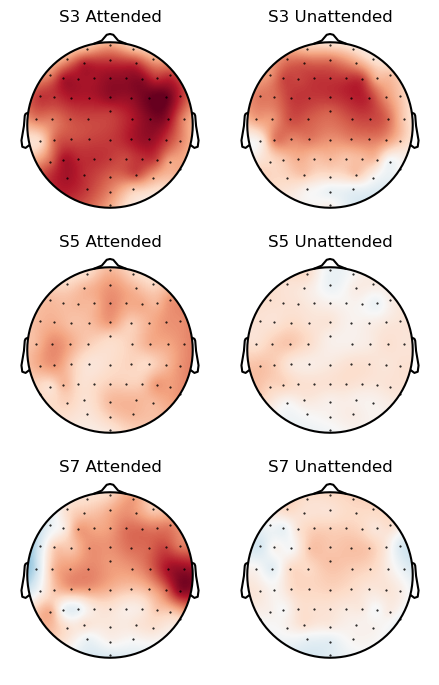

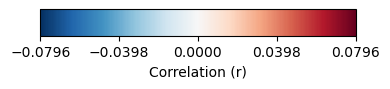

In [25]:
# Select subjects
subjects_to_plot = [3, 5, 7]

plots_flat = []
titles = []

for s in subjects_to_plot:
    plots_flat.append(attended_corr[s])
    plots_flat.append(unattended_corr[s])
    titles.extend([f"S{s} Attended", f"S{s} Unattended"])

# Global color scaling
all_data = np.concatenate([ndvar.x.flatten() for ndvar in plots_flat])
absmax = np.max(np.abs(all_data))
vmin, vmax = -absmax, absmax

# Create Topomap
p = eelbrain.plot.Topomap(
    plots_flat,
    axtitle=titles,
    cmap='RdBu_r',
    vmin=vmin,
    vmax=vmax,
    clip='circle',
)

p.plot_colorbar(label="Correlation (r)", ticks=5)

# ---- Save using pyplot ----
fig = p.figure  # get matplotlib figure from eelbrain
fig.savefig(file_paths.FIGURES_DIR / 'topomaps.pdf', dpi=300)


In [26]:
cases = []
for subject in SUBJECTS:
    for attention, name in zip(['attended', 'unattended'], ['attended', 'unattended']):
        trf = eelbrain.load.unpickle(file_paths.TRF_DIR / subject / f"{subject}_{name}_trf.pickle")
        prediction_accuracy = trf.proportion_explained * 100  # to %
        cases.append([subject, trf.h, prediction_accuracy, attention])

column_names = ['subject', 'trf', 'prediction_accuracy','attention']
data_trfs = eelbrain.Dataset.from_caselist(column_names, cases, random='subject')

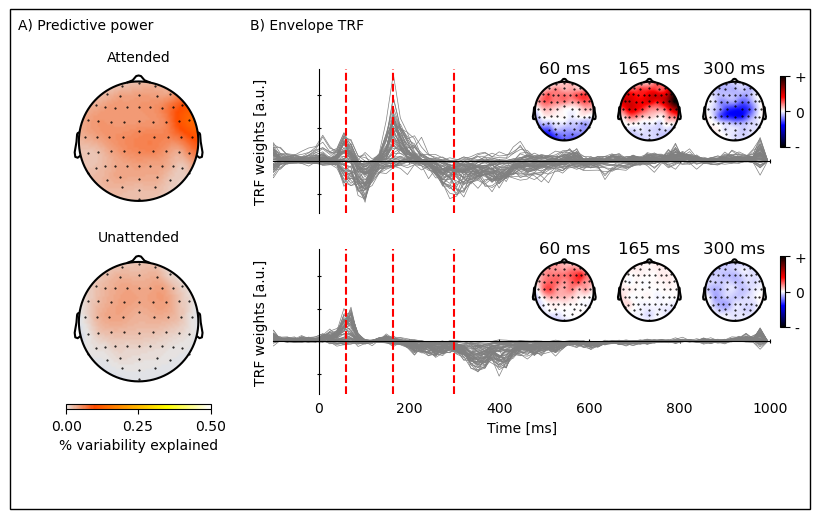

In [27]:
# Initialize figure
figure = plt.figure(figsize=(8, 5))
gridspec = figure.add_gridspec(7, 9, left=0.01, right=0.95, hspace=1.5)
topo_args = dict(clip='circle')
det_args = dict(**topo_args, vmax=0.5, cmap='lux-gray')
trf_vmax = 0.007
labels = {
    'attended': 'attended', 
    'unattended': 'unattended', 
}

# A) Prediction accuracies 
for attention_idx, attention in enumerate(labels):
    axes = figure.add_subplot(gridspec[attention_idx*3: attention_idx*3+3, 0:3])
    p = eelbrain.plot.Topomap('prediction_accuracy', data=data_trfs[data_trfs['attention']==attention], axes=axes, **det_args)
    label = labels[attention]
    axes.set_title(f"{label.capitalize()}", loc='center', size=10)
p.plot_colorbar(below=axes, label="% variability explained", clipmin=0, ticks=5, h=2)

# B) data_TRFs 
times = [0.06, 0.165, 0.30]
time_labels = ['%d ms' % (time*1000) for time in times]
for attention_idx, attention in enumerate(labels):
    axes = figure.add_subplot(gridspec[attention_idx*3: attention_idx*3+3, 3:9])
    reference_index = data_trfs['attention'] == attention
    trf = data_trfs[reference_index, 'trf']
    
    # Plot butterfly TRF
    kwargs = dict(vmin=-0.004, vmax=0.007, linewidth=0.5, color='#808080', ylabel='TRF weights [a.u.]', frame='t', yticklabels='none', xlim=(-0.100, 1.000), clip=True)
    if attention_idx != 1:
        kwargs.update(dict(xticklabels='none', xlabel=''))
    plot = eelbrain.plot.Butterfly(trf, axes=axes, **kwargs)
    for time in times:
        plot.add_vline(time, color='r', linestyle='--')

    # Plot topomaps
    axes = [
        figure.add_subplot(gridspec[attention_idx*3: attention_idx*3+2, 6]),
        figure.add_subplot(gridspec[attention_idx*3: attention_idx*3+2, 7]),
        figure.add_subplot(gridspec[attention_idx*3: attention_idx*3+2, 8]),
    ]
    plot_topo = eelbrain.plot.Topomap([trf.sub(time=time) for time in times], axes=axes, axtitle=time_labels, columns=len(times), vmax=trf_vmax, **topo_args)
    plot_topo.plot_colorbar(right_of=axes[-1], label='', label_rotation=90, ticks={trf_vmax:'+', -trf_vmax:'-', 0:'0'})

figure.text(0.01, 0.96, 'A) Predictive power', size=10)
figure.text(0.30, 0.96, 'B) Envelope TRF', size=10)

figure.savefig(file_paths.FIGURES_DIR / 'topo-butterflies.pdf')
eelbrain.plot.figure_outline()

# Statistical difference between attended and unattended speech

In [28]:
att = np.array(mean_attended_corr)
unatt = np.array(mean_unattended_corr)

# Fisher transform
att_z = np.arctanh(att)
unatt_z = np.arctanh(unatt)

# Paired test
t, p = stats.ttest_rel(att_z, unatt_z)

print("t =", t)
print("p =", p)

t = 3.638948667268027
p = 0.0020298269386077893
